In [1]:
import pandas as pd
import numpy as np

In [2]:
import os, sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.models.quantile_regression import QuantileRegressionV1
from src.optimizers.Nesterov import NesterovOptimizer

In [4]:
data = pd.read_csv("../../dataset/foodDeli_processed/train_processed.csv")

In [5]:
data.head()

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Preparation_Time,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Road_traffic_density_Jam,...,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Vehicle_condition_1,Vehicle_condition_2,Festival_Yes,City_Semi-Urban,City_Urban,Time_taken
0,1.283313,0.846622,-1.202059,1.228728,0,0,0,1,0,0,...,0,1,1,0,0,1,0,0,1,24
1,0.762428,-0.418372,2.263776,-1.218497,0,0,1,0,0,1,...,0,1,0,1,0,1,0,0,0,33
2,-1.147486,-0.734620,-1.118905,1.228728,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,26
3,1.456942,0.214125,-0.035496,0.005115,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,21
4,0.415171,-0.102123,-0.613995,1.228728,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,30


In [6]:
np.random.seed(42)
shuffled_indices = np.random.permutation(len(data))

train_size = int(len(data) * 0.8)

data_train = data.iloc[shuffled_indices[:train_size]]
data_test = data.iloc[shuffled_indices[train_size:]]

In [7]:
X_train = np.array(data_train.drop(columns="Time_taken"))
y_train = np.array(data_train["Time_taken"])
X_test = np.array(data_test.drop(columns="Time_taken"))
y_test = np.array(data_test["Time_taken"])

In [8]:
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [32]:
nesterov = NesterovOptimizer(lr=0.1)

In [33]:
model = QuantileRegressionV1(optimizer=nesterov)

In [34]:
model.fit(X_train, y_train, epochs=50000)

Epoch 0/50000, Loss: 23.8476
Epoch 100/50000, Loss: 1.6424
Epoch 200/50000, Loss: 1.4942
Epoch 300/50000, Loss: 1.4218
Epoch 400/50000, Loss: 1.3778
Epoch 500/50000, Loss: 1.3471
Epoch 600/50000, Loss: 1.3228
Epoch 700/50000, Loss: 1.3026
Epoch 800/50000, Loss: 1.2852
Epoch 900/50000, Loss: 1.2697
Epoch 1000/50000, Loss: 1.2556
Epoch 1100/50000, Loss: 1.2429
Epoch 1200/50000, Loss: 1.2312
Epoch 1300/50000, Loss: 1.2202
Epoch 1400/50000, Loss: 1.2101
Epoch 1500/50000, Loss: 1.2007
Epoch 1600/50000, Loss: 1.1920
Epoch 1700/50000, Loss: 1.1839
Epoch 1800/50000, Loss: 1.1763
Epoch 1900/50000, Loss: 1.1693
Epoch 2000/50000, Loss: 1.1627
Epoch 2100/50000, Loss: 1.1567
Epoch 2200/50000, Loss: 1.1512
Epoch 2300/50000, Loss: 1.1461
Epoch 2400/50000, Loss: 1.1414
Epoch 2500/50000, Loss: 1.1371
Epoch 2600/50000, Loss: 1.1331
Epoch 2700/50000, Loss: 1.1294
Epoch 2800/50000, Loss: 1.1260
Epoch 2900/50000, Loss: 1.1229
Epoch 3000/50000, Loss: 1.1200
Epoch 3100/50000, Loss: 1.1173
Epoch 3200/50000, L

In [35]:
loss = model.loss

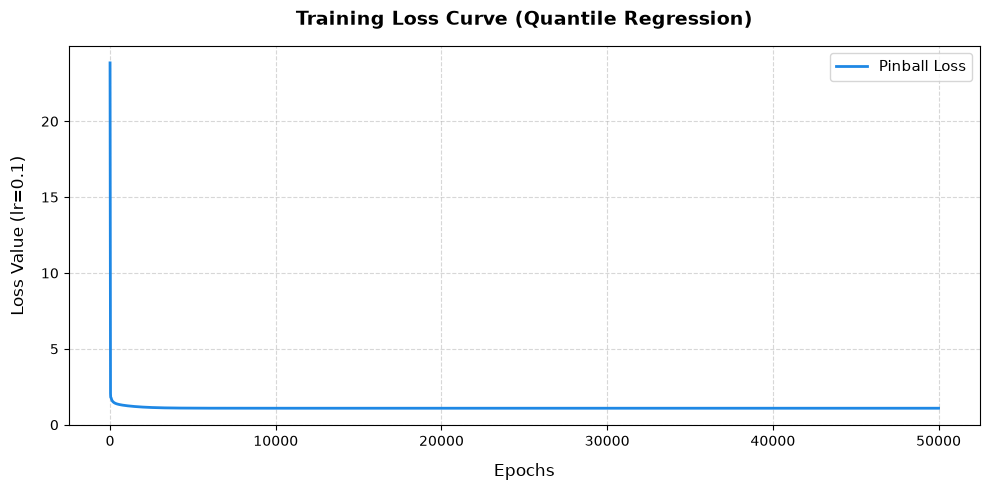

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss, label='Pinball Loss', color='#1E88E5', linewidth=2)

plt.title('Training Loss Curve (Quantile Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, labelpad=10)
plt.ylabel('Loss Value (lr=0.1)', fontsize=12, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [37]:
y_pred = model.predict(X_test)

test_pinball_loss = model.pinball_loss(y_test, y_pred)
test_mae = np.mean(np.abs(y_test - y_pred))
test_rmse = np.sqrt(np.mean((y_test - y_pred)**2))

coverage_ratio = np.mean(y_test <= y_pred)

print(f"Test Pinball Loss (tau=0.9): {test_pinball_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test Coverage Ratio: {coverage_ratio:.4f}")

Test Pinball Loss (tau=0.9): 1.0786
Test MAE: 8.5126
Test RMSE: 10.0994
Test Coverage Ratio: 0.8960


In [38]:
model.save_weights("../../results/weights/Nesterov/nesterov_weights.npy")

Saved.


In [39]:
np.save("../../results/weights/Nesterov/nesterov_loss_1.npy", np.array(loss))
print("Đã lưu biến loss thành công.")

Đã lưu biến loss thành công.


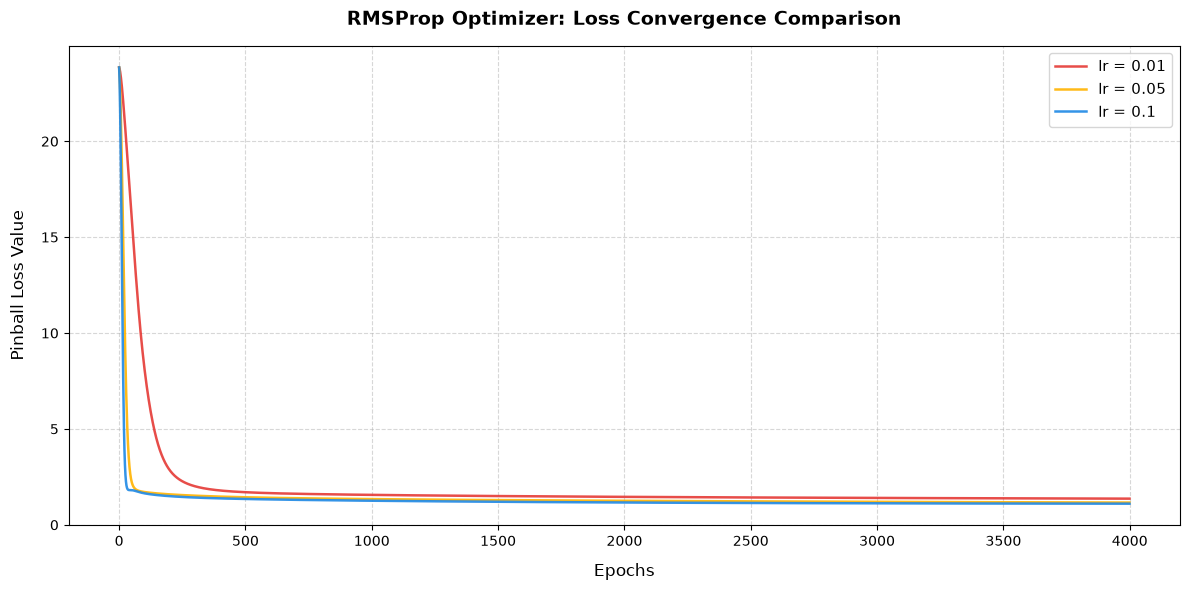

In [40]:
# 1. Đọc dữ liệu loss từ các tệp .npy
# (Đường dẫn tương đối tính từ thư mục notebooks/training/)
loss_01 = np.load("../../results/weights/Nesterov/nesterov_loss_01.npy")
loss_05 = np.load("../../results/weights/Nesterov/nesterov_loss_05.npy")
loss_1 = np.load("../../results/weights/Nesterov/nesterov_loss_1.npy")

# 2. Khởi tạo biểu đồ so sánh
plt.figure(figsize=(12, 6))

# Vẽ 3 đường với các màu sắc tương phản rõ nét
plt.plot(loss_01[:4000], label='lr = 0.01', color='#E53935', linewidth=1.8, alpha=0.9)
plt.plot(loss_05[:4000], label='lr = 0.05', color='#FFB300', linewidth=1.8, alpha=0.9)
plt.plot(loss_1[:4000], label='lr = 0.1', color='#1E88E5', linewidth=1.8, alpha=0.9)

# Cấu hình tiêu đề và các trục tọa độ
plt.title('RMSProp Optimizer: Loss Convergence Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, labelpad=10)
plt.ylabel('Pinball Loss Value', fontsize=12, labelpad=10)

# Cấu hình lưới bổ trợ (grid) và ghi chú (legend)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Tối ưu hóa khoảng cách hiển thị
plt.tight_layout()

# Hiển thị đồ thị
plt.show()